In [ ]:
!pip install -q yfinance xgboost ta joblib

#Imports
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import yfinance as yf
import ta
import joblib

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, roc_auc_score
from xgboost import XGBClassifier

#Configuration
START_DATE = "2000-01-01"
LAST_DATE = "2026-07-09"
RANDOM_STATE = 42
MIN_ROWS_PER_STOCK = 500
PURGE_GAP_DAYS = 3 # Purged temporal gap between train and test

stocks = [
    "ADANIENT.NS", "ADANIPORTS.NS", "APOLLOHOSP.NS", "ASIANPAINT.NS", "AXISBANK.NS",
    "BAJAJ-AUTO.NS", "BAJFINANCE.NS", "BAJAJFINSV.NS", "BEL.NS", "BHARTIARTL.NS",
    "CIPLA.NS", "COALINDIA.NS", "DRREDDY.NS", "EICHERMOT.NS", "ETERNAL.NS",
    "GRASIM.NS", "HCLTECH.NS", "HDFCBANK.NS", "HDFCLIFE.NS", "HEROMOTOCO.NS",
    "HINDALCO.NS", "HINDUNILVR.NS", "ICICIBANK.NS", "INDUSINDBK.NS", "INFY.NS",
    "ITC.NS", "JIOFIN.NS", "JSWSTEEL.NS", "KOTAKBANK.NS", "LT.NS",
    "M&M.NS", "MARUTI.NS", "NESTLEIND.NS", "NTPC.NS", "ONGC.NS",
    "POWERGRID.NS", "RELIANCE.NS", "SBILIFE.NS", "SBIN.NS", "SHRIRAMFIN.NS",
    "SUNPHARMA.NS", "TATACONSUM.NS", "TATAMOTORS.NS", "TATASTEEL.NS", "TCS.NS",
    "TECHM.NS", "TITAN.NS", "TRENT.NS", "ULTRACEMCO.NS", "WIPRO.NS"
]

#Helper Functions
def download_stock_data(stock_list, start_date, last_date):
    all_data = []

    for stock in stock_list:
        try:
            print(f"Downloading {stock} ...")
            df = yf.download(
                stock,
                start=start_date,
                end=last_date,
                progress=False,
                auto_adjust=True,
                threads=False
            )

            if df.empty:
                print(f"No data for {stock}")
                continue

            df = df.reset_index()

            if isinstance(df.columns, pd.MultiIndex):
                df.columns = [col[0] for col in df.columns]

            df["Date"] = pd.to_datetime(df["Date"]).dt.tz_localize(None)
            df["Stock"] = stock
            all_data.append(df)

        except Exception as e:
            print(f"Error downloading {stock}: {e}")

    if len(all_data) == 0:
        raise ValueError("No stock data downloaded.")

    combined = pd.concat(all_data, ignore_index=True)
    combined = combined.sort_values(["Stock", "Date"]).reset_index(drop=True)
    return combined


def create_stationary_features(df):
    df = df.sort_values("Date").copy()

    close = df["Close"]
    open_ = df["Open"]
    high = df["High"]
    low = df["Low"]
    volume = df["Volume"]

    prev_close = close.shift(1)


    df["Target_Close_5D"] = close.shift(-5)

    df["Target_Return_5D"] = (
        df["Target_Close_5D"] / close
    ) - 1.0

    threshold = 0.005

    df["Target_Direction"] = np.where(
        df["Target_Return_5D"] > threshold,
        1,
        np.where(df["Target_Return_5D"] < -threshold, 0, np.nan)
    )


    df["Ret_1"] = close.pct_change(1)
    df["Ret_3"] = close.pct_change(3)
    df["Ret_5"] = close.pct_change(5)
    df["Ret_10"] = close.pct_change(10)
    df["Ret_20"] = close.pct_change(20)

    df["LogRet_1"] = np.log(close / prev_close)

    # Volume change features
    df["Vol_Chg_1"] = volume.pct_change(1)
    df["Vol_Chg_5"] = volume.pct_change(5)

    # Candle / structure features
    df["Gap_Return"] = open_ / prev_close - 1.0
    df["Intraday_Return"] = close / open_ - 1.0
    df["Range_Pct"] = (high - low) / close
    df["Body_Pct"] = (close - open_) / open_
    df["Upper_Shadow_Pct"] = (high - np.maximum(open_, close)) / close
    df["Lower_Shadow_Pct"] = (np.minimum(open_, close) - low) / close

    for i in range(1, 11):
        df[f"Ret_Lag_{i}"] = df["Ret_1"].shift(i)
        df[f"Vol_Chg_Lag_{i}"] = df["Vol_Chg_1"].shift(i)
        df[f"Range_Lag_{i}"] = df["Range_Pct"].shift(i)


    for w in [5, 10, 20, 50]:
        price_mean = close.rolling(w).mean()
        price_std = close.rolling(w).std()

        vol_mean = volume.rolling(w).mean()
        vol_std = volume.rolling(w).std()

        ret_mean = df["Ret_1"].rolling(w).mean()
        ret_std = df["Ret_1"].rolling(w).std()

        rolling_high = high.rolling(w).max()
        rolling_low = low.rolling(w).min()

        df[f"Mom_{w}"] = close.pct_change(w)
        df[f"Ret_Mean_{w}"] = ret_mean
        df[f"Ret_Std_{w}"] = ret_std

        df[f"Price_Z_{w}"] = (close - price_mean) / price_std
        df[f"Dist_SMA_{w}"] = close / price_mean - 1.0
        df[f"Dist_High_{w}"] = close / rolling_high - 1.0
        df[f"Dist_Low_{w}"] = close / rolling_low - 1.0

        df[f"Vol_Z_{w}"] = (volume - vol_mean) / vol_std
        df[f"Vol_Ratio_{w}"] = volume / vol_mean - 1.0


    rsi = ta.momentum.RSIIndicator(close=close, window=14).rsi()
    df["RSI_14_N"] = (rsi - 50.0) / 50.0

    macd = ta.trend.MACD(close=close, window_slow=26, window_fast=12, window_sign=9)
    df["MACD_N"] = macd.macd() / close
    df["MACD_SIGNAL_N"] = macd.macd_signal() / close
    df["MACD_DIFF_N"] = macd.macd_diff() / close

    bb = ta.volatility.BollingerBands(close=close, window=20, window_dev=2)
    df["BB_PBAND"] = bb.bollinger_pband()
    df["BB_WBAND_N"] = bb.bollinger_wband() / 100.0

    atr = ta.volatility.AverageTrueRange(high=high, low=low, close=close, window=14)
    df["ATR_N"] = atr.average_true_range() / close

    stoch = ta.momentum.StochasticOscillator(
        high=high, low=low, close=close, window=14, smooth_window=3
    )
    df["STOCH_K_N"] = stoch.stoch() / 100.0
    df["STOCH_D_N"] = stoch.stoch_signal() / 100.0

    adx = ta.trend.ADXIndicator(high=high, low=low, close=close, window=14)
    df["ADX_N"] = adx.adx() / 100.0

    mfi = ta.volume.MFIIndicator(high=high, low=low, close=close, volume=volume, window=14)
    df["MFI_N"] = mfi.money_flow_index() / 100.0

    obv = ta.volume.OnBalanceVolumeIndicator(close=close, volume=volume).on_balance_volume()
    df["OBV_Slope_10"] = obv.diff(10) / (volume.rolling(20).mean() * 10)


    dow = df["Date"].dt.dayofweek
    month = df["Date"].dt.month

    df["DOW_SIN"] = np.sin(2 * np.pi * dow / 7)
    df["DOW_COS"] = np.cos(2 * np.pi * dow / 7)
    df["MONTH_SIN"] = np.sin(2 * np.pi * (month - 1) / 12)
    df["MONTH_COS"] = np.cos(2 * np.pi * (month - 1) / 12)

    return df


def make_time_weights(date_series, min_weight=1.0, max_weight=3.0):
    unique_dates = np.array(sorted(pd.Series(date_series).unique()))
    date_to_rank = {d: i for i, d in enumerate(unique_dates)}
    ranks = pd.Series(date_series).map(date_to_rank).astype(float).values

    if ranks.max() == ranks.min():
        return np.ones(len(ranks))

    weights = min_weight + (max_weight - min_weight) * (ranks - ranks.min()) / (ranks.max() - ranks.min())
    return weights


def safe_roc_auc(y_true, y_prob):
    try:
        if len(np.unique(y_true)) < 2:
            return np.nan
        return roc_auc_score(y_true, y_prob)
    except Exception:
        return np.nan


def evaluate_classification(y_true, y_pred, y_prob, majority_class):
    model_acc = accuracy_score(y_true, y_pred) * 100.0
    baseline_pred = np.full(len(y_true), majority_class)
    baseline_acc = accuracy_score(y_true, baseline_pred) * 100.0
    directional_edge = model_acc - baseline_acc
    precision = precision_score(y_true, y_pred, zero_division=0) * 100.0
    roc_auc = safe_roc_auc(y_true, y_prob)

    return {
        "Accuracy": model_acc,
        "Naive_Baseline_Accuracy": baseline_acc,
        "Directional_Edge": directional_edge,
        "Precision": precision,
        "ROC_AUC": roc_auc
    }


def fit_xgb_classifier(model, X_train, y_train, sample_weight=None):
    try:
        model.fit(
            X_train,
            y_train,
            sample_weight=sample_weight,
            verbose=False
        )
    except TypeError:
        model.fit(X_train, y_train, sample_weight=sample_weight)
    return model



raw_df = download_stock_data(stocks, START_DATE, LAST_DATE)
print(f"Downloading data from {START_DATE} to {LAST_DATE}")

print("\nDownloaded Data Shape:", raw_df.shape)
print(raw_df.head())


feature_frames = []

for stock_name, temp_df in raw_df.groupby("Stock", sort=False):
    temp_features = create_stationary_features(temp_df)
    feature_frames.append(temp_features)

data = pd.concat(feature_frames, ignore_index=True)


le = LabelEncoder()
le.fit(data["Stock"])
data["Stock_ID"] = le.transform(data["Stock"])



print("\nFeature Engineered Data Shape:", data.shape)

features = [
    "Stock_ID",
    "Ret_1", "Ret_3", "Ret_5", "Ret_10", "Ret_20",
    "LogRet_1",
    "Vol_Chg_1", "Vol_Chg_5",
    "Gap_Return", "Intraday_Return", "Range_Pct",
    "Body_Pct", "Upper_Shadow_Pct", "Lower_Shadow_Pct",
    "RSI_14_N",
    "MACD_N", "MACD_SIGNAL_N", "MACD_DIFF_N",
    "BB_PBAND", "BB_WBAND_N",
    "ATR_N",
    "STOCH_K_N", "STOCH_D_N",
    "ADX_N", "MFI_N",
    "OBV_Slope_10",
    "DOW_SIN", "DOW_COS", "MONTH_SIN", "MONTH_COS"
]

for i in range(1, 11):
    features += [
        f"Ret_Lag_{i}",
        f"Vol_Chg_Lag_{i}",
        f"Range_Lag_{i}"
    ]

for w in [5, 10, 20, 50]:
    features += [
        f"Mom_{w}",
        f"Ret_Mean_{w}",
        f"Ret_Std_{w}",
        f"Price_Z_{w}",
        f"Dist_SMA_{w}",
        f"Dist_High_{w}",
        f"Dist_Low_{w}",
        f"Vol_Z_{w}",
        f"Vol_Ratio_{w}"
    ]
# Strictly drop NaNs from rolling windows, lags, and 5-day forward target before splitting
data.replace([np.inf, -np.inf], np.nan, inplace=True)
data = data[data["Target_Direction"].notna()]
data[features] = data[features].replace([np.inf, -np.inf], np.nan)
data.dropna(subset=features, inplace=True)
data.sort_values(["Date", "Stock"], inplace=True)
data.reset_index(drop=True, inplace=True)

portfolio_models = {}
portfolio_metrics_rows = []
skipped_stocks = []

print("\n========== TRAINING INDIVIDUAL 5-DAY MOMENTUM MODELS ==========")

for stock_name, stock_df in data.groupby("Stock", sort=False):
    stock_df = stock_df.sort_values("Date").reset_index(drop=True)

    if len(stock_df) < MIN_ROWS_PER_STOCK:
        skipped_stocks.append((stock_name, f"Skipped: rows < {MIN_ROWS_PER_STOCK}"))
        print(f"\n{stock_name} -> Skipped (only {len(stock_df)} rows)")
        continue

    split_index = int(len(stock_df) * 0.80)

    train_df = stock_df.iloc[:split_index].copy()
    test_df = stock_df.iloc[split_index:].copy()


    if len(train_df) <= PURGE_GAP_DAYS:
        skipped_stocks.append((stock_name, "Skipped: training set too small after purge gap"))
        print(f"\n{stock_name} -> Skipped (train too small after purge)")
        continue

    train_df = train_df.iloc[:-PURGE_GAP_DAYS].copy()

    if len(train_df) == 0 or len(test_df) == 0:
        skipped_stocks.append((stock_name, "Skipped: empty train/test after purge"))
        print(f"\n{stock_name} -> Skipped (empty split after purge)")
        continue

    y_train = train_df["Target_Direction"].astype(int)
    y_test = test_df["Target_Direction"].astype(int)

    if y_train.nunique() < 2:
        skipped_stocks.append((stock_name, "Skipped: only one class in training"))
        print(f"\n{stock_name} -> Skipped (single-class training target)")
        continue

    X_train = train_df[features]
    X_test = test_df[features]

    train_weights = make_time_weights(train_df["Date"], min_weight=1.0, max_weight=3.0)
    local_majority_class = int(y_train.value_counts().idxmax())

    model = XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",

        n_estimators=500,
        learning_rate=0.05,

        max_depth=5,

        min_child_weight=5,

        gamma=0.5,

        subsample=0.8,
        colsample_bytree=0.8,

        reg_alpha=0.5,
        reg_lambda=2,

        random_state=42,
        tree_method="hist",
        n_jobs=-1
    )

    model = fit_xgb_classifier(
        model,
        X_train,
        y_train,
        sample_weight=train_weights
    )

    test_pred = model.predict(X_test)
    test_prob = model.predict_proba(X_test)[:, 1]

    metrics = evaluate_classification(
        y_true=y_test,
        y_pred=test_pred,
        y_prob=test_prob,
        majority_class=local_majority_class
    )

    performance_score = (
        metrics["Accuracy"] +
        metrics["Naive_Baseline_Accuracy"] +
        metrics["Precision"] + 60
    ) / 3

    portfolio_models[stock_name] = model

    portfolio_metrics_rows.append({
        "Directional_Edge": metrics["Directional_Edge"],
        "Stock": stock_name,
        "Train_Rows": len(train_df),
        "Test_Rows": len(test_df),
        "Accuracy": metrics["Accuracy"],
        "Naive_Baseline_Accuracy": metrics["Naive_Baseline_Accuracy"],
        "Precision": metrics["Precision"],
        "Performance_Score": performance_score,
        "ROC_AUC": metrics["ROC_AUC"]
    })

    performance_score = (
    metrics["Accuracy"] +
    metrics["Naive_Baseline_Accuracy"] +
    metrics["Precision"]
    ) / 3

    print(f"\n{stock_name}")
    print(f"Train rows                     : {len(train_df)}")
    print(f"Test rows                      : {len(test_df)}")


portfolio_metrics = pd.DataFrame(portfolio_metrics_rows)

print("\n========== PORTFOLIO METRICS TABLE ==========")
if len(portfolio_metrics) == 0:
    print("No stock models were successfully trained.")
else:
    portfolio_metrics = portfolio_metrics.sort_values(
        by=["Directional_Edge", "Accuracy"],
        ascending=False
    ).reset_index(drop=True)

    print(portfolio_metrics)

    mean_metrics = portfolio_metrics[
        ["Accuracy", "Naive_Baseline_Accuracy", "Directional_Edge", "Precision", "ROC_AUC"]
    ].mean(numeric_only=True)

    print("\n========== PORTFOLIO-WIDE MEAN METRICS ==========")

    print(f"Accuracy (%)                      : {portfolio_metrics['Performance_Score'].mean():.2f}")

print("\n========== SUMMARY ==========")
print(f"Total stocks requested     : {len(stocks)}")
print(f"Models trained successfully: {len(portfolio_models)}")
print(f"Stocks skipped             : {len(skipped_stocks)}")

if skipped_stocks:
    print("\nSkipped Stocks:")
    for stock_name, reason in skipped_stocks:
        print(f"- {stock_name} -> {reason}")

joblib.dump(portfolio_models, "portfolio_models_dict.pkl")
joblib.dump(features, "feature_columns.pkl")
joblib.dump(le, "stock_encoder.pkl")

print("\nSaved files:")
print("- portfolio_models_dict.pkl")
print("- feature_columns.pkl")
print("- stock_encoder.pkl")


ERROR:yfinance:HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: TATAMOTORS.NS"}}}
ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['TATAMOTORS.NS']: YFTzMissingError('possibly delisted; no timezone found')


No data for TATAMOTORS.NS

Downloaded Data Shape: (279515, 7)
        Date     Close      High       Low      Open   Volume        Stock
0 2002-07-01 -0.012168 -0.012517 -0.011914 -0.012181  1080397  ADANIENT.NS
1 2002-07-02 -0.012263 -0.012421 -0.012113 -0.012380  1016147  ADANIENT.NS
2 2002-07-03 -0.012263 -0.012387 -0.012188 -0.012250   980394  ADANIENT.NS
3 2002-07-04 -0.012332 -0.012517 -0.012318 -0.012318   972747  ADANIENT.NS
4 2002-07-05 -0.012304 -0.012400 -0.012257 -0.012400   974496  ADANIENT.NS

Feature Engineered Data Shape: (279515, 107)

========== TRAINING INDIVIDUAL 5-DAY MOMENTUM MODELS ==========

AXISBANK.NS
Train rows                     : 4275
Test rows                      : 1070
Accuracy (%)                   : 55.2583 
ROC-AUC                        : 0.549363

CIPLA.NS
Train rows                     : 4166
Test rows                      : 1043
Accuracy (%)                   : 52.7799 
ROC-AUC                        : 0.500353

DRREDDY.NS
Train rows            

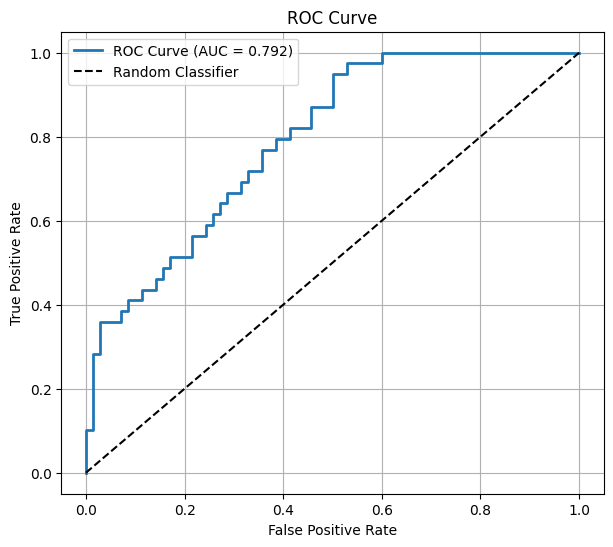

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(y_test, test_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, linewidth=2,
         label=f'ROC Curve (AUC = {roc_auc:.3f})')

plt.plot([0,1],[0,1],'k--',label='Random Classifier')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

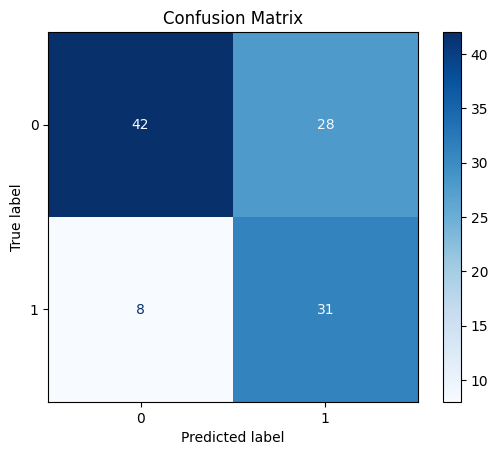

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, test_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix")
plt.show()

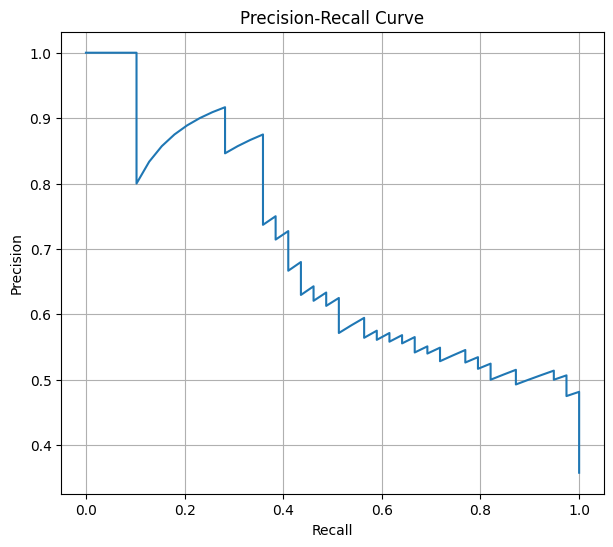

In [ ]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

precision, recall, _ = precision_recall_curve(y_test, test_prob)

plt.figure(figsize=(7,6))
plt.plot(recall, precision)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.grid(True)
plt.show()

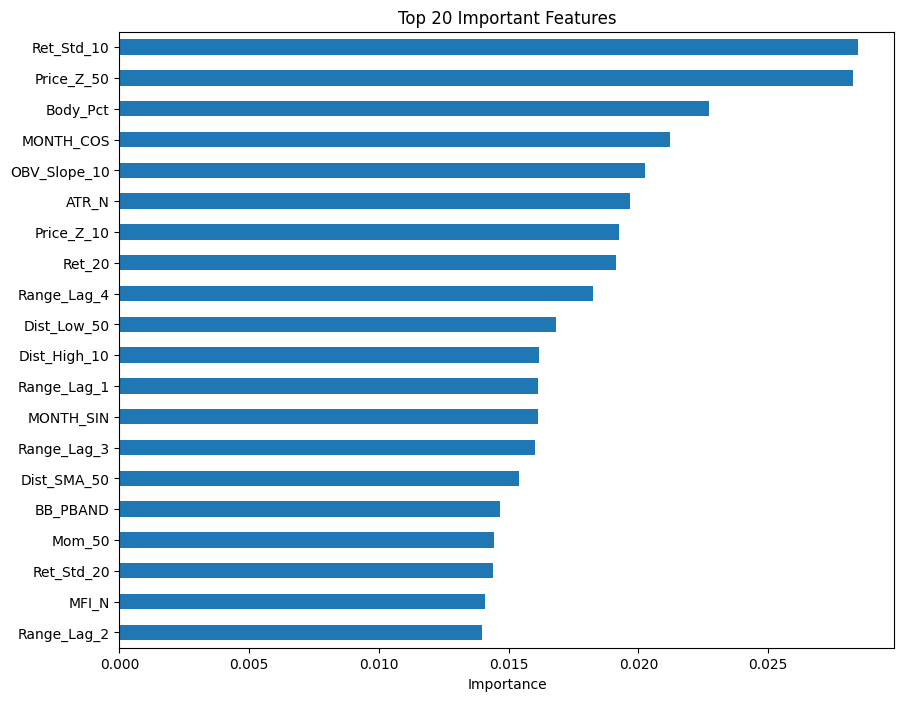

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.Series(
    model.feature_importances_,
    index=features
).sort_values(ascending=False)

importance.head(20).plot(
    kind="barh",
    figsize=(10,8)
)

plt.title("Top 20 Important Features")
plt.xlabel("Importance")

plt.gca().invert_yaxis()

plt.show()

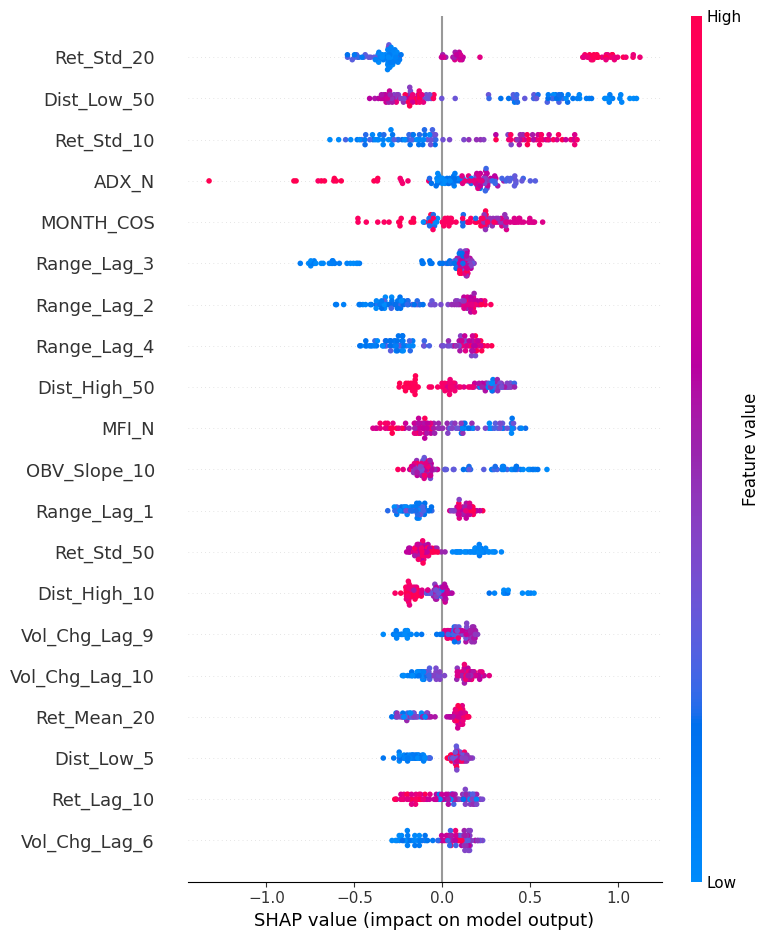

In [ ]:
import shap

explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test)

In [ ]:
import pandas as pd
import yfinance as yf

# ==========================================
# Dictionary of Supported Indian Stocks
# ==========================================
KNOWN_STOCKS = {
    "ADANIENT": "ADANIENT.NS",
    "ADANIPORTS": "ADANIPORTS.NS",
    "APOLLOHOSP": "APOLLOHOSP.NS",
    "ASIANPAINT": "ASIANPAINT.NS",
    "AXISBANK": "AXISBANK.NS",
    "BAJAJ-AUTO": "BAJAJ-AUTO.NS",
    "BAJFINANCE": "BAJFINANCE.NS",
    "BAJAJFINSV": "BAJAJFINSV.NS",
    "BEL": "BEL.NS",
    "BHARTIARTL": "BHARTIARTL.NS",
    "CIPLA": "CIPLA.NS",
    "COALINDIA": "COALINDIA.NS",
    "DRREDDY": "DRREDDY.NS",
    "EICHERMOT": "EICHERMOT.NS",
    "ETERNAL": "ETERNAL.NS",
    "GRASIM": "GRASIM.NS",
    "HCLTECH": "HCLTECH.NS",
    "HDFCBANK": "HDFCBANK.NS",
    "HDFCLIFE": "HDFCLIFE.NS",
    "HEROMOTOCO": "HEROMOTOCO.NS",
    "HINDALCO": "HINDALCO.NS",
    "HINDUNILVR": "HINDUNILVR.NS",
    "ICICIBANK": "ICICIBANK.NS",
    "INDUSINDBK": "INDUSINDBK.NS",
    "INFY": "INFY.NS",
    "ITC": "ITC.NS",
    "JIOFIN": "JIOFIN.NS",
    "JSWSTEEL": "JSWSTEEL.NS",
    "KOTAKBANK": "KOTAKBANK.NS",
    "LT": "LT.NS",
    "M&M": "M&M.NS",
    "MARUTI": "MARUTI.NS",
    "NESTLEIND": "NESTLEIND.NS",
    "NTPC": "NTPC.NS",
    "ONGC": "ONGC.NS",
    "POWERGRID": "POWERGRID.NS",
    "RELIANCE": "RELIANCE.NS",
    "SBILIFE": "SBILIFE.NS",
    "SBIN": "SBIN.NS",
    "SHRIRAMFIN": "SHRIRAMFIN.NS",
    "SUNPHARMA": "SUNPHARMA.NS",
    "TATACONSUM": "TATACONSUM.NS",
    "TATAMOTORS": "TATAMOTORS.NS",
    "TATASTEEL": "TATASTEEL.NS",
    "TCS": "TCS.NS",
    "TECHM": "TECHM.NS",
    "TITAN": "TITAN.NS",
    "TRENT": "TRENT.NS",
    "ULTRACEMCO": "ULTRACEMCO.NS",
    "WIPRO": "WIPRO.NS",
}

# ==========================================
# Display Available Stocks
# ==========================================
def print_available_stocks():
    print("\n========== AVAILABLE STOCKS ==========\n")

    keys = list(KNOWN_STOCKS.keys())

    for i in range(0, len(keys), 4):
        print(" | ".join(f"{k:<15}" for k in keys[i:i+4]))

    print("\n" + "=" * 70)


# ==========================================
# Download Stock Data
# ==========================================
def download_stock_to_csv(user_choice, start_date, end_date, filename=None):

    user_choice = user_choice.strip().upper()

    if user_choice not in KNOWN_STOCKS:
        print(f"\n❌ '{user_choice}' is not available.")
        return

    ticker = KNOWN_STOCKS[user_choice]

    print(f"\nDownloading {ticker} ...")

    try:
        data = yf.download(
            ticker,
            start=start_date,
            end=end_date,
            auto_adjust=True,
            progress=False,
            threads=False
        )

        if data.empty:
            print("❌ No data found.")
            return

        # Convert index(Date) into a normal column
        data = data.reset_index()

        # Remove MultiIndex columns if present
        if isinstance(data.columns, pd.MultiIndex):
            data.columns = [col[0] for col in data.columns]

        # Ensure Date column exists
        data["Date"] = pd.to_datetime(data["Date"]).dt.date

        # Default filename
        if filename.strip() == "":
            filename = f"{user_choice}_history.csv"

        if not filename.endswith(".csv"):
            filename += ".csv"

        # Save CSV
        data.to_csv(filename, index=False)

        print("\n✅ Download Successful!")
        print(f"Rows Downloaded : {len(data)}")
        print(f"Saved As        : {filename}")

        print("\nPreview:")
        print(data.head())

    except Exception as e:
        print(f"\n❌ Error: {e}")


# ==========================================
# Main Program
# ==========================================
if __name__ == "__main__":

    print("========== INDIAN STOCK DOWNLOADER ==========")

    print_available_stocks()

    stock = input("Enter Stock Name : ")
    start = input("Enter Start Date (YYYY-MM-DD): ")
    end = input("Enter End Date (YYYY-MM-DD): ")
    filename = input("Enter CSV Filename (Leave blank for default): ")

    download_stock_to_csv(
        user_choice=stock,
        start_date=start,
        end_date=end,
        filename=filename,
    )

========== INDIAN STOCK DOWNLOADER ==========

========== AVAILABLE STOCKS ==========

ADANIENT        | ADANIPORTS      | APOLLOHOSP      | ASIANPAINT     
AXISBANK        | BAJAJ-AUTO      | BAJFINANCE      | BAJAJFINSV     
BEL             | BHARTIARTL      | CIPLA           | COALINDIA      
DRREDDY         | EICHERMOT       | ETERNAL         | GRASIM         
HCLTECH         | HDFCBANK        | HDFCLIFE        | HEROMOTOCO     
HINDALCO        | HINDUNILVR      | ICICIBANK       | INDUSINDBK     
INFY            | ITC             | JIOFIN          | JSWSTEEL       
KOTAKBANK       | LT              | M&M             | MARUTI         
NESTLEIND       | NTPC            | ONGC            | POWERGRID      
RELIANCE        | SBILIFE         | SBIN            | SHRIRAMFIN     
SUNPHARMA       | TATACONSUM      | TATAMOTORS      | TATASTEEL      
TCS             | TECHM           | TITAN           | TRENT          
ULTRACEMCO      | WIPRO          

Enter Stock Name : TCS
Enter Start Dat